## Imports

In [3]:
%%capture
!pip install numpy pandas pyarrow tqdm onnxruntime torch

In [1]:
# Core Python
import os
import sys
import warnings
warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Utils
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import HistGradientBoostingRegressor

# Tensorflow Utils
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    TensorBoard
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import (
    BinaryCrossentropy,
    CategoricalCrossentropy,
    MeanSquaredError
)


## Load Dataset

In [6]:
## Download
!curl -L https://files.wundernn.io/wnn_predictorium_starterpack.tar.gz | tar -xz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring 

In [2]:
train = pd.read_parquet('/content/competition_package/datasets/train.parquet')
test = pd.read_parquet('/content/competition_package/datasets/valid.parquet')

In [3]:
# Sample data
def sample_sequences(df, n_sequences, seed=42):
    np.random.seed(seed)

    unique_seqs = df["seq_ix"].unique()
    sampled_seqs = np.random.choice(unique_seqs,
                                     size=n_sequences,
                                     replace=False)

    return df[df["seq_ix"].isin(sampled_seqs)].copy()

train = sample_sequences(train, n_sequences=200)
valid = sample_sequences(test, n_sequences=100)

## EDA

In [10]:
## Structure Check
display(train.shape)
display(train.head())
display(train.info())
display(train.describe())
test.head()

(10721000, 37)

,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,dp0,dp1,dp2,dp3,dv0,dv1,dv2,dv3,t0,t1
0,0,0,0,1.077446,-0.710366,0.373591,0.835558,0.050204,-0.139710,1.367384,...,-0.031078,-0.053527,-0.475214,-0.410787,0.805692,0.516635,-0.368215,-0.503497,-0.564226,1.864018
1,0,1,0,1.100140,-0.562796,0.483658,0.875354,0.138444,-0.010037,1.354714,...,0.950145,-0.083598,-0.604252,-0.703991,-1.925171,1.252957,-1.563974,-1.929990,-0.239079,2.168843
2,0,2,0,1.100140,-0.562796,0.483658,0.875354,0.138444,-0.010037,1.870266,...,-0.168259,1.632066,-0.178565,0.121240,1.377339,1.803970,-0.402838,1.042579,2.237778,2.459723
3,0,3,0,0.955471,-1.486537,0.230353,0.676854,-0.262686,-0.366873,2.011996,...,-0.426942,-0.743530,0.680013,1.394857,0.785266,1.424660,1.258192,0.914074,1.998699,2.272444
4,0,4,0,1.025123,-0.832006,0.317650,0.759677,-0.062770,-0.230353,2.174650,...,0.195700,0.293986,0.494971,0.267884,-1.315502,1.775372,1.302424,1.355667,1.998699,2.324245


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10721000 entries, 0 to 10720999
Data columns (total 37 columns):
 #   Column           Dtype  
---  ------           -----  
 0   seq_ix           int64  
 1   step_in_seq      int64  
 2   need_prediction  int8   
 3   p0               float64
 4   p1               float64
 5   p2               float64
 6   p3               float64
 7   p4               float64
 8   p5               float64
 9   p6               float64
 10  p7               float64
 11  p8               float64
 12  p9               float64
 13  p10              float64
 14  p11              float64
 15  v0               float64
 16  v1               float64
 17  v2               float64
 18  v3               float64
 19  v4               float64
 20  v5               float64
 21  v6               float64
 22  v7               float64
 23  v8               float64
 24  v9               float64
 25  v10              float64
 26  v11              float64
 27  dp0       

None

,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,dp0,dp1,dp2,dp3,dv0,dv1,dv2,dv3,t0,t1
count,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,...,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07
mean,5.360000e+03,4.995000e+02,9.010000e-01,1.406910e+00,-1.210059e+00,4.081931e-01,8.513727e-01,-1.252726e-01,-2.773504e-01,1.524261e+00,...,1.360129e-02,-8.331481e-02,1.342347e-01,-6.546184e-02,-2.485630e-01,4.986747e-01,9.317593e-02,-3.397429e-01,-1.662297e-01,-5.598812e-02
std,3.094886e+03,2.886750e+02,2.986620e-01,4.601623e-01,5.517048e-01,1.567414e-01,2.362825e-01,2.834494e-01,2.435492e-01,4.377065e-01,...,1.127798e+00,9.587646e-01,9.474122e-01,9.302200e-01,9.905516e-01,8.823766e-01,8.152566e-01,1.058391e+00,8.570684e-01,1.127213e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,5.630160e-01,-5.199338e+00,-3.303641e+00,-3.176243e+00,-5.199338e+00,-5.199338e+00,6.699961e-01,...,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-3.439378e+01,-5.565436e+01
25%,2.680000e+03,2.497500e+02,1.000000e+00,1.025123e+00,-1.525529e+00,3.176496e-01,7.270122e-01,-1.982585e-01,-3.521514e-01,1.218002e+00,...,-6.671782e-01,-7.249732e-01,-5.932789e-01,-6.675830e-01,-9.495473e-01,-1.638238e-01,-3.955639e-01,-1.089397e+00,-6.311681e-01,-5.387243e-01
50%,5.360000e+03,4.995000e+02,1.000000e+00,1.299272e+00,-1.192071e+00,3.735909e-01,8.063648e-01,-6.276963e-02,-2.316411e-01,1.365257e+00,...,4.015699e-02,-1.587398e-01,4.088051e-01,-1.283173e-01,-1.816520e-01,5.336357e-01,8.919250e-02,-1.816520e-01,-2.390788e-01,-5.487970e-02
75%,8.040000e+03,7.492500e+02,1.000000e+00,1.597698e+00,-8.320063e-01,5.049220e-01,8.847827e-01,3.128636e-02,-1.727310e-01,1.721914e+00,...,7.750452e-01,4.483604e-01,8.266977e-01,5.049732e-01,4.459191e-01,1.095177e+00,6.104835e-01,3.924920e-01,8.606838e-02,4.315373e-01
max,1.072000e+04,9.990000e+02,1.000000e+00,5.199338e+00,3.944545e+00,5.199338e+00,5.199338e+00,5.199338e+00,3.270130e+00,5.199338e+00,...,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,7.942821e+01,5.388353e+01


,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,dp0,dp1,dp2,dp3,dv0,dv1,dv2,dv3,t0,t1
0,0,0,0,0.892038,-0.546700,0.293986,0.728240,0.115678,-0.018820,1.803203,...,-0.030025,0.836811,0.336509,-1.254820,-0.163824,-0.163824,-0.163824,-0.163824,-0.491662,-0.031387
1,0,1,0,1.059682,-0.658043,0.404717,0.754664,0.076604,-0.077862,2.056872,...,0.610484,-0.724973,0.522099,-0.286135,-0.163824,-0.163824,-0.163824,-0.163824,-0.375888,0.065718
2,0,2,0,1.035790,-0.832006,0.330873,0.705530,-0.006273,-0.172731,2.065579,...,0.084155,-0.445919,0.658043,-0.383024,-0.163824,-0.163824,-0.163824,-0.163824,-0.375888,0.071983
3,0,3,0,1.307063,-0.853480,0.504922,0.773140,0.020074,-0.153660,2.279624,...,0.598435,-1.004131,0.832006,-0.602943,-0.163824,-0.163824,-0.163824,-0.163824,-0.375888,0.170653
4,0,4,0,1.059682,-0.658043,0.404717,0.754664,0.076604,-0.077862,1.739312,...,0.288750,-0.046436,0.555462,-0.949547,-0.163824,-0.163824,-0.163824,-0.163824,-0.187944,0.270890


In [14]:
# Number of sequences
display(train["seq_ix"].nunique())

# Check length per sequence
display(train.groupby("seq_ix")["step_in_seq"].count().describe())

# Verify step range
train.groupby("seq_ix")["step_in_seq"].agg(["min", "max"]).head()

10721

,step_in_seq
count,10721.0
mean,1000.0
std,0.0
min,1000.0
25%,1000.0
50%,1000.0
75%,1000.0
max,1000.0


,min,max
seq_ix,,
0,0,999
1,0,999
2,0,999
3,0,999
4,0,999


In [15]:
# Missing
train.isnull().sum().sort_values(ascending=False).head(20)

,0
seq_ix,0
step_in_seq,0
need_prediction,0
p0,0
p1,0
p2,0
p3,0
p4,0
p5,0
p6,0


In [16]:
# Organize based on Readme.md
price_cols = [c for c in train.columns if c.startswith("p")]
volume_cols = [c for c in train.columns if c.startswith("v")]
trade_price_cols = [c for c in train.columns if c.startswith("dp")]
trade_volume_cols = [c for c in train.columns if c.startswith("dv")]
target_cols = ["t0", "t1"]

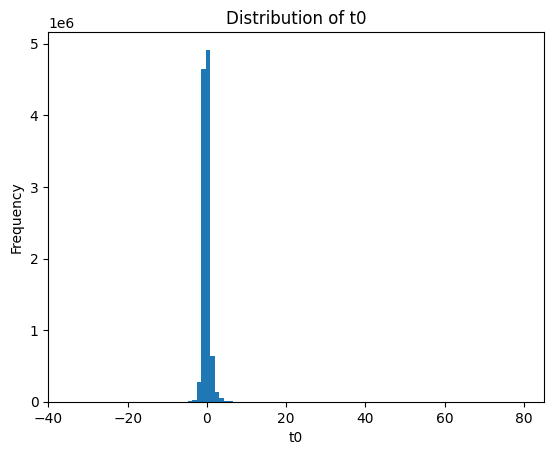

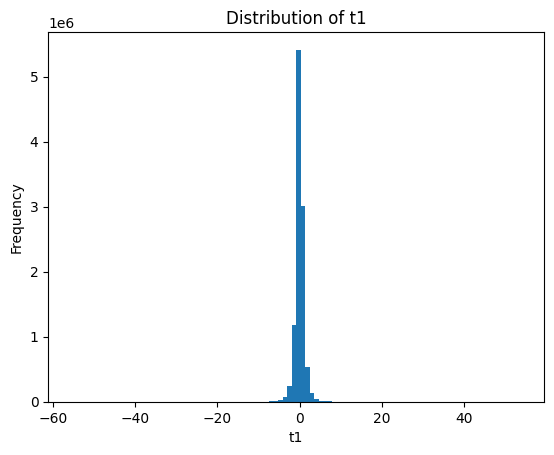

In [18]:
# Target has extreme tails (relevant for the eval metric)
for col in target_cols:
    plt.figure()
    plt.hist(train[col].dropna(), bins=100)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [21]:
for col in target_cols:
    print(col, (train[col].abs() > 6).mean())
    print(col, (train[col].abs() > 6).sum())


t0 0.0009646488200727544
t0 10342
t1 0.002806268072008208
t1 30086


In [22]:
corr = train[price_cols + volume_cols + target_cols].corr()

# plt.figure(figsize=(10,6))
# sns.heatmap(corr.loc[target_cols, :], cmap="coolwarm", center=0)
# plt.title("Correlation of Features with Targets")
# plt.show()


KeyboardInterrupt: 

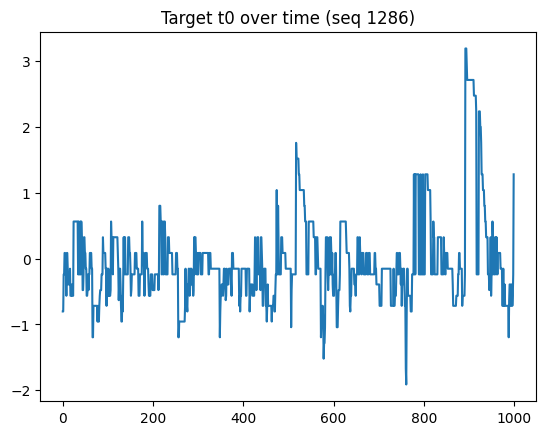

In [5]:
seq_id = train["seq_ix"].sample(1).values[0]
seq_data = train[train["seq_ix"] == seq_id].sort_values("step_in_seq")

plt.figure()
plt.plot(seq_data["step_in_seq"], seq_data["t0"])
plt.title(f"Target t0 over time (seq {seq_id})")
plt.show()


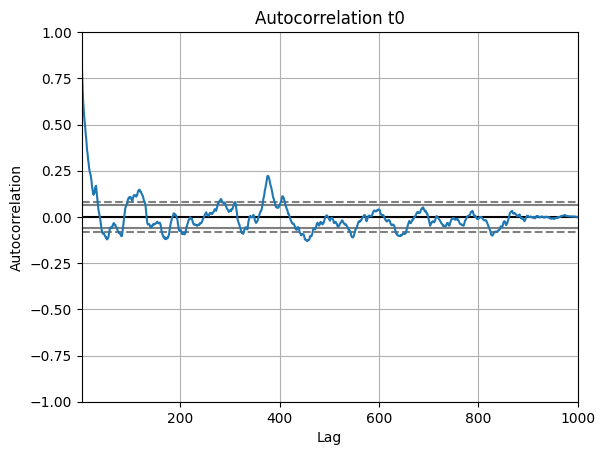

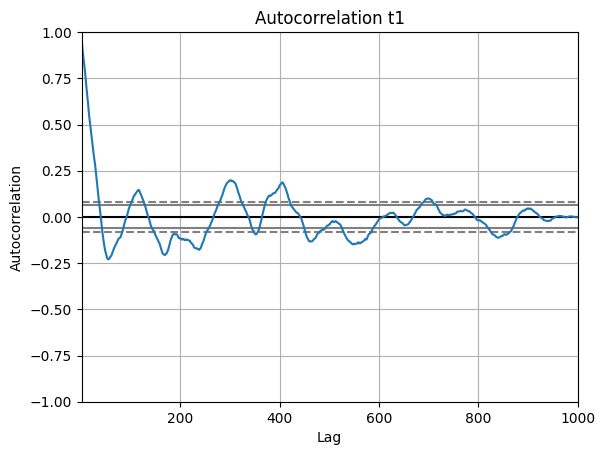

In [8]:
from pandas.plotting import autocorrelation_plot

plt.figure()
autocorrelation_plot(seq_data["t0"])
plt.title("Autocorrelation t0")
plt.show()


plt.figure()
autocorrelation_plot(seq_data["t1"])
plt.title("Autocorrelation t1")
plt.show()

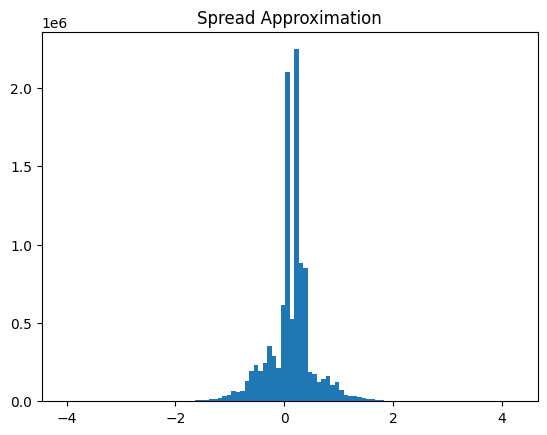

In [10]:
train["spread_approx"] = train["p6"] - train["p0"]
plt.hist(train["spread_approx"], bins=100)
plt.title("Spread Approximation")
plt.show()


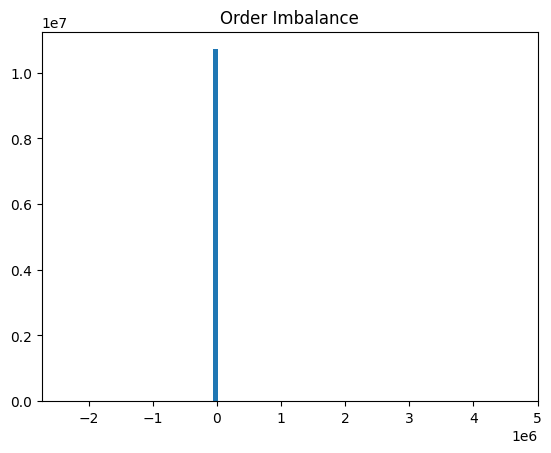

In [11]:
train["bid_volume_sum"] = train[[f"v{i}" for i in range(6)]].sum(axis=1)
train["ask_volume_sum"] = train[[f"v{i}" for i in range(6,12)]].sum(axis=1)

train["order_imbalance"] = (
    (train["bid_volume_sum"] - train["ask_volume_sum"]) /
    (train["bid_volume_sum"] + train["ask_volume_sum"] + 1e-9)
)

plt.hist(train["order_imbalance"], bins=100)
plt.title("Order Imbalance")
plt.show()


In [12]:
train[["order_imbalance", "t0", "t1"]].corr()

,order_imbalance,t0,t1
order_imbalance,1.000000,0.000464,0.000611
t0,0.000464,1.000000,0.505823
t1,0.000611,0.505823,1.000000


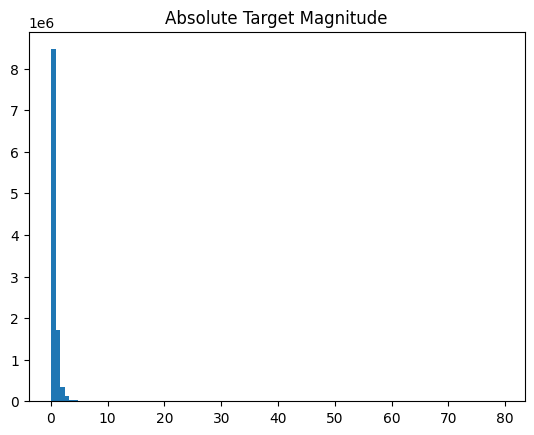

In [13]:
train["abs_t0"] = train["t0"].abs()
train["abs_t1"] = train["t1"].abs()

plt.hist(train["abs_t0"], bins=100)
plt.title("Absolute Target Magnitude")
plt.show()

In [14]:
high_amp = train[train["abs_t0"] > train["abs_t0"].quantile(0.9)]

high_amp.corr().loc["t0"].sort_values(ascending=False).head(10)


,t0
t0,1.000000
t1,0.699928
abs_t0,0.469698
spread_approx,0.213830
abs_t1,0.167928
p8,0.157979
p4,0.156296
p1,0.153315
v8,0.146758
dp2,0.132834


In [16]:
high_amp = train[train["abs_t1"] > train["abs_t1"].quantile(0.9)]

high_amp.corr().loc["t1"].sort_values(ascending=False).head(10)


,t1
t1,1.000000
t0,0.562735
abs_t0,0.279037
dv2,0.058075
spread_approx,0.054930
dv3,0.053668
dp3,0.053095
v1,0.049586
v8,0.049338
dp2,0.045607


In [17]:
# Check sequence-level target variance
seq_stats = train.groupby("seq_ix")[["t0", "t1"]].std()

seq_stats.describe()


,t0,t1
count,10721.000000,10721.000000
mean,0.786443,0.924540
std,0.324378,0.600663
min,0.275271,0.139892
25%,0.592776,0.559418
50%,0.713450,0.757111
75%,0.886331,1.095280
max,7.383015,11.946976


## Modeling

In [6]:
def weighted_pearson(y_true, y_pred):
    # Clip predictions
    y_pred = np.clip(y_pred, -6, 6)

    weights = np.abs(y_true)

    # Weighted means
    mean_true = np.sum(weights * y_true) / np.sum(weights)
    mean_pred = np.sum(weights * y_pred) / np.sum(weights)

    # Weighted covariance
    cov = np.sum(weights * (y_true - mean_true) * (y_pred - mean_pred))

    # Weighted variances
    var_true = np.sum(weights * (y_true - mean_true)**2)
    var_pred = np.sum(weights * (y_pred - mean_pred)**2)

    return cov / np.sqrt(var_true * var_pred + 1e-12)


### Baseline - Naive Previous Values Pred

In [4]:
import numpy as np
import pandas as pd

train_sorted = train.sort_values(["seq_ix", "step_in_seq"]).copy()

# Shift targets within each sequence
for target in ["t0", "t1"]:
    train_sorted[f"pred_{target}"] = (
        train_sorted.groupby("seq_ix")[target].shift(1)
    )


mask = (
    (train_sorted["step_in_seq"] >= 99) &
    (~train_sorted["pred_t0"].isna())
)

eval_df = train_sorted.loc[mask].copy()


In [7]:
score_t0 = weighted_pearson(
    eval_df["t0"].values,
    eval_df["pred_t0"].values
)

score_t1 = weighted_pearson(
    eval_df["t1"].values,
    eval_df["pred_t1"].values
)

final_score = (score_t0 + score_t1) / 2

print("t0 score:", score_t0)
print("t1 score:", score_t1)
print("Final score:", final_score)


t0 score: 0.762968653221847
t1 score: 0.9857324500893504
Final score: 0.8743505516555987


In [8]:
# Sort properly
valid_sorted = test.sort_values(["seq_ix", "step_in_seq"]).copy()

# Naive previous-step predictor
for target in ["t0", "t1"]:
    valid_sorted[f"pred_{target}"] = (
        valid_sorted.groupby("seq_ix")[target].shift(1)
    )

# Remove warmup + first step
mask = (
    (valid_sorted["step_in_seq"] >= 99) &
    (~valid_sorted["pred_t0"].isna())
)

eval_valid = valid_sorted.loc[mask].copy()

In [9]:
score_t0_valid = weighted_pearson(
    eval_valid["t0"].values,
    eval_valid["pred_t0"].values
)

score_t1_valid = weighted_pearson(
    eval_valid["t1"].values,
    eval_valid["pred_t1"].values
)

final_score_valid = (score_t0_valid + score_t1_valid) / 2

print("Validation t0 score:", score_t0_valid)
print("Validation t1 score:", score_t1_valid)
print("Validation final score:", final_score_valid)


Validation t0 score: 0.6377991600542117
Validation t1 score: 0.9142366963157654
Validation final score: 0.7760179281849886


### HGBG

### TF

## Save to Github

In [10]:
!git config --global user.email "abishpius@gmail.com"
!git config --global user.name "Abish Pius"

In [11]:
from google.colab import userdata
import requests

token = userdata.get('github')
repo_name = "wonderfund-quant-forecasting"
username = "abishpius"
message = "WunderFund Quant Forecasting Challenge"
notebook_name = "WunderFundForecasting_Challenge.ipynb"

headers = {
    "Authorization": f"token {token}",
    "Accept": "application/vnd.github+json"
}

# === CHECK IF REPO EXISTS ===
check_url = f"https://api.github.com/repos/{username}/{repo_name}"
check_resp = requests.get(check_url, headers=headers)

if check_resp.status_code == 200:
    print(f"❌ Repo '{repo_name}' already exists at: https://github.com/{username}/{repo_name}")
else:
    # === CREATE REPO ===
    create_url = "https://api.github.com/user/repos"
    payload = {
        "name": repo_name,
        "auto_init": True,
        "private": False  # change to True if you want a private repo
    }

    create_resp = requests.post(create_url, headers=headers, json=payload)

    if create_resp.status_code == 201:
        print(f"✅ Repo '{repo_name}' created successfully.")

        # === UPDATE README.md ===
        import base64

        update_url = f"https://api.github.com/repos/{username}/{repo_name}/contents/README.md"
        readme_text = ""
        encoded = base64.b64encode(readme_text.encode()).decode()
        update_payload = {
            "message": message,
            "content": encoded,
            "sha": requests.get(update_url, headers=headers).json()["sha"]
        }

        update_resp = requests.put(update_url, headers=headers, json=update_payload)

        if update_resp.status_code == 200 or update_resp.status_code == 201:
            print("✅ README.md updated with custom text.")
        else:
            print("⚠️ Failed to update README.md:", update_resp.json())

    else:
        print("❌ Repo creation failed:", create_resp.json())

✅ Repo 'wonderfund-quant-forecasting' created successfully.
✅ README.md updated with custom text.


In [12]:
!git clone https://{token}@github.com/{username}/{repo_name}.git

# === MOVE NOTEBOOK ===
import shutil
shutil.copy(f"/content/drive/MyDrive/Colab Notebooks/{notebook_name}", f"/content/{repo_name}/{notebook_name}")

# === COMMIT TO REPO ===
%cd {repo_name}
!git add {notebook_name}
!git commit -m "EDA initial + Naive Models"
!git push

Cloning into 'wonderfund-quant-forecasting'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/WunderFundForecasting_Challenge.ipynb'